## EDA

In [268]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style(
    style='darkgrid', 
    rc={'axes.facecolor': 'white', 'grid.color': '.8'}
)

In [269]:
# load database
df_final = pd.read_csv("../data/df_final.csv", parse_dates=["timestamp"])
print(df_final.shape)
print(df_final.columns.tolist())

(62728, 30)
['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar', 'hour', 'day_of_week', 'month', 'temperature', 'wind_speed', 'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h', 'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h', 'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation', 'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation', 'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar', 'actual_load']


In [270]:
df_final.tail()

,timestamp,price,load,wind_offshore,wind_onshore,solar,hour,day_of_week,month,temperature,...,is_hol_or_week,total_generation,net_export,coal_generation,gas_generation,nuclear_generation,actual_wind_offshore,actual_wind_onshore,actual_solar,actual_load
62723,2026-03-05 18:00:00,192.02,65144.30,2949.89,11933.60,79.03,18,3,3,9.262501,...,False,55386.48,9851.50,17506.93,7544.73,0.0,4125.25,13861.12,29.47,62356.17
62724,2026-03-05 19:00:00,165.00,64387.12,3532.01,15822.87,0.00,19,3,3,8.412500,...,False,59769.96,11767.75,17140.25,7502.69,0.0,4724.38,19962.83,0.29,62865.91
62725,2026-03-05 20:00:00,135.25,61639.86,3770.35,17757.48,0.00,20,3,3,7.550000,...,False,60044.93,13357.73,16691.22,7177.71,0.0,5164.78,22421.03,0.00,60565.71
62726,2026-03-05 21:00:00,130.59,58043.48,3633.21,17964.93,0.00,21,3,3,6.825000,...,False,58359.74,14699.75,16486.76,6235.84,0.0,5099.88,22264.34,0.00,57190.45
62727,2026-03-05 22:00:00,130.14,54547.59,3259.55,16587.78,0.00,22,3,3,6.099999,...,False,55448.25,15444.47,16640.32,6234.20,0.0,4445.18,20106.16,0.00,53594.19


### Price Series Understanding

In [271]:
# Summary stats by year
df_final.groupby(df_final["timestamp"].dt.year)["price"].describe()

,count,mean,std,min,25%,50%,75%,max
timestamp,,,,,,,,
2019,8591.0,37.635030,15.161344,-90.01,31.060,37.98,46.000,121.46
2020,8783.0,30.474167,17.498852,-83.94,21.760,30.99,40.250,200.04
2021,8759.0,96.853094,73.684554,-69.00,53.005,75.48,112.035,620.00
2022,8759.0,235.461584,142.810249,-19.04,134.255,208.37,310.080,871.00
2023,8759.0,95.186317,47.576064,-500.00,75.885,98.02,122.120,524.27
2024,8783.0,78.511610,52.729396,-135.45,55.550,79.58,101.340,936.28
2025,8759.0,89.331746,52.096417,-250.32,71.100,92.43,114.145,583.40
2026,1535.0,103.545303,36.700664,-0.79,87.615,101.32,119.735,310.86


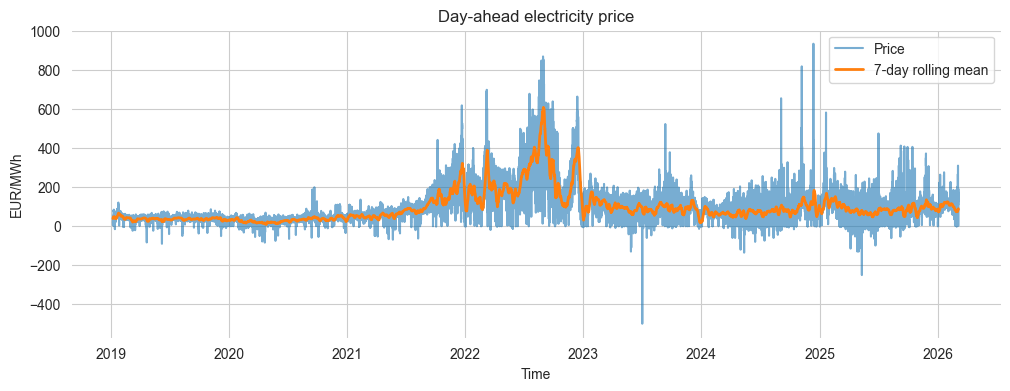

In [272]:
# Plot full price time series with rolling (7-day) mean

plt.figure(figsize=(12,4))

# original price
plt.plot(df_final["timestamp"],
         df_final["price"],
         alpha=0.6,
         label="Price")

# rolling mean (7-day example)
plt.plot(df_final["timestamp"],
         df_final["price_rolling_168h"],
         linewidth=2,
         label="7-day rolling mean")

plt.grid(True, axis='y')
plt.title("Day-ahead electricity price")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()

In [273]:
# Create 30-day rolling mean and standard deviation
df_final['price_rolling_720h'] = df_final['price'].rolling(window=720).mean()
df_final['volatility_rolling_720h'] = df_final['price'].rolling(window=720).std()

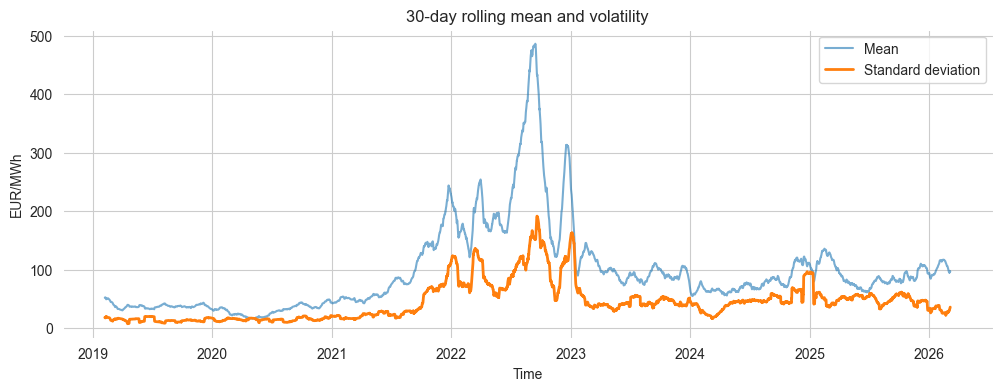

In [274]:
# Plot 30-day rolling mean and standard deviation (price volatility)
plt.figure(figsize=(12,4))

# original price
plt.plot(df_final["timestamp"],
         df_final["price_rolling_720h"],
         alpha=0.6,
         label="Mean")

# rolling mean (7-day example)
plt.plot(df_final["timestamp"],
         df_final["volatility_rolling_720h"],
         linewidth=2,
         label="Standard deviation")

plt.grid(True, axis='y')
plt.title("30-day rolling mean and volatility")
plt.xlabel("Time")
plt.ylabel("EUR/MWh")
plt.legend()

In [275]:
# show lowest and highest percentile of price distribution
# full ts
print(df_final['price'].describe(percentiles=[0.01, 0.99]))
# from 2023
print(df_final[df_final['timestamp'].dt.year>2022]['price'].describe(percentiles=[0.01, 0.99]))

count    62728.000000
mean        95.115812
std         92.900814
min       -500.000000
1%          -9.900000
50%         75.900000
99%        480.020000
max        936.280000
Name: price, dtype: float64
count    27836.000000
mean        88.543728
std         50.752558
min       -500.000000
1%         -13.075000
50%         91.010000
99%        222.059500
max        936.280000
Name: price, dtype: float64


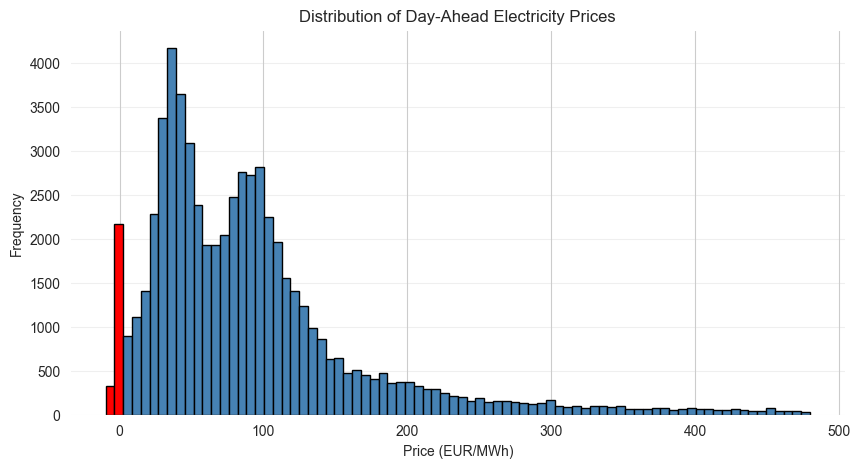

In [276]:
# Price Histogram

# drop lowest and highest percentile to see the distribution better
data = df_final[(df_final['price']>-9.9) & (df_final['price']<480)]["price"]

plt.figure(figsize=(10,5))

# create histogram (but don't draw yet)
counts, bins, patches = plt.hist(
    data,
    bins=80,
    edgecolor="black"
)

# color bars
for bin_left, patch in zip(bins[:-1], patches):
    if bin_left < 0:
        patch.set_facecolor("red")
    else:
        patch.set_facecolor("steelblue")

plt.title("Distribution of Day-Ahead Electricity Prices")
plt.xlabel("Price (EUR/MWh)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

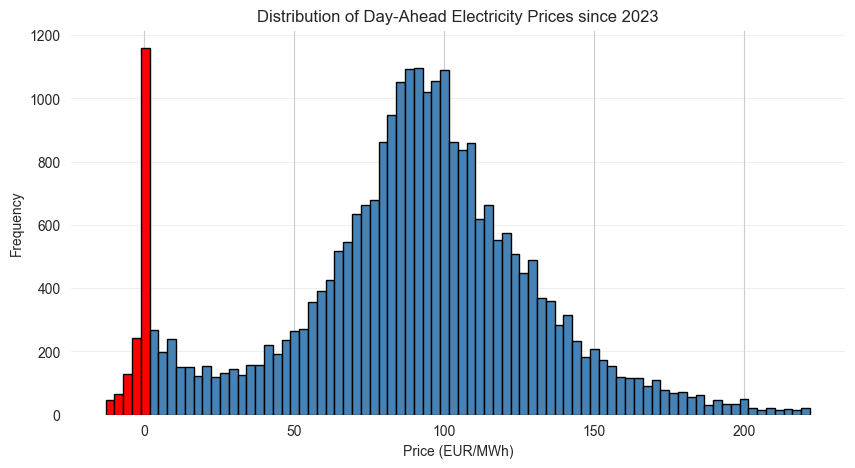

In [277]:
# Price Histogram since 2023

# show only from 2023
data = df_final[(df_final['price']>-13) & (df_final['price']<222) & (df_final['timestamp'].dt.year>2022)]["price"]

plt.figure(figsize=(10,5))

# create histogram (but don't draw yet)
counts, bins, patches = plt.hist(
    data,
    bins=80,
    edgecolor="black"
)

# color bars
for bin_left, patch in zip(bins[:-1], patches):
    if bin_left < 0:
        patch.set_facecolor("red")
    else:
        patch.set_facecolor("steelblue")

plt.title("Distribution of Day-Ahead Electricity Prices since 2023")
plt.xlabel("Price (EUR/MWh)")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)

plt.show()

### Time structure, seasonality

In [278]:
# add more time indicators
df_final = df_final.assign(
    timestamp = lambda x: pd.to_datetime(x['timestamp']), 
    date = lambda x: x['timestamp'].dt.date,
    year = lambda x: x['timestamp'].dt.year,
    day = lambda x: x['timestamp'].dt.day,
    dayofyear = lambda x: x['timestamp'].dt.dayofyear,
    weekofyear = lambda x: x['timestamp'].dt.isocalendar().week
)
df_final.columns


Index(['timestamp', 'price', 'load', 'wind_offshore', 'wind_onshore', 'solar',
       'hour', 'day_of_week', 'month', 'temperature', 'wind_speed',
       'is_weekend', 'gas_price', 'coal_price', 'price_lag_24h',
       'price_lag_168h', 'price_rolling_24h', 'price_rolling_168h',
       'co2_price', 'is_holiday', 'is_hol_or_week', 'total_generation',
       'net_export', 'coal_generation', 'gas_generation', 'nuclear_generation',
       'actual_wind_offshore', 'actual_wind_onshore', 'actual_solar',
       'actual_load', 'price_rolling_720h', 'volatility_rolling_720h', 'date',
       'year', 'day', 'dayofyear', 'weekofyear'],
      dtype='object')

In [279]:
# Aggregate price by day - since 2023

daily_data_df = df_final[(df_final['timestamp'].dt.year>2022)] \
    .groupby(['date', 'year', 'month', 'day', 'dayofyear', 'weekofyear', 'day_of_week'], as_index=False)\
    .agg({'price': np.mean}) \
    .set_index('date')


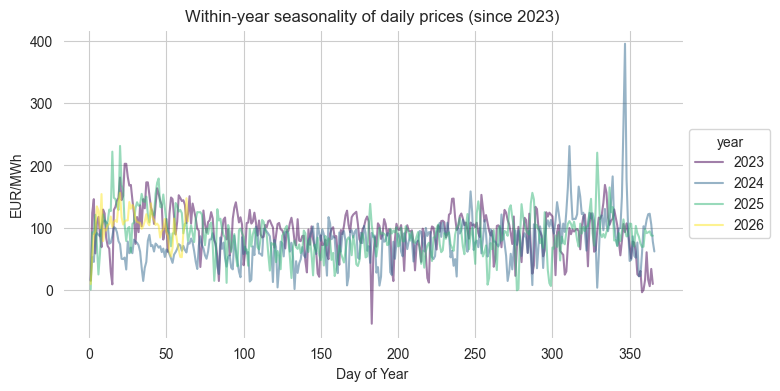

In [280]:
# Inspect seasonality within a year
fig, ax = plt.subplots(figsize=(8,4)) 

pd.pivot_table(data=daily_data_df[['year', 'dayofyear', 'price']], index='dayofyear', columns='year') \
    ['price'] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title='Within-year seasonality of daily prices (since 2023)', ylabel=r'EUR/MWh', xlabel='Day of Year');

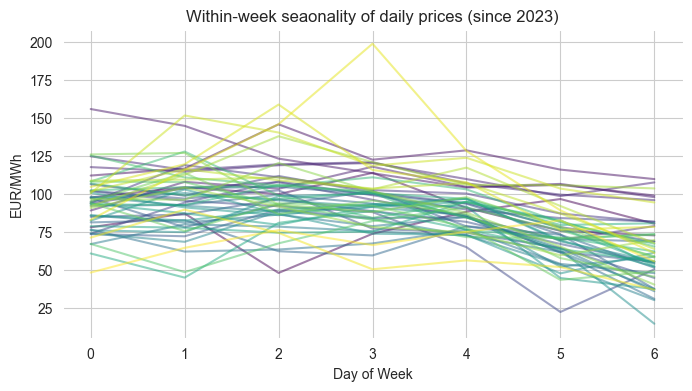

In [281]:
# Inspect seasonality within a week
fig, ax = plt.subplots(figsize=(8,4)) 

pd.pivot_table(data=daily_data_df[['weekofyear', 'day_of_week', 'price']], index='day_of_week', columns='weekofyear') \
    ['price'] \
    .plot(cmap='viridis', alpha=0.5, ax=ax, legend=False)

ax.set(title='Within-week seaonality of daily prices (since 2023)', ylabel=r'EUR/MWh', xlabel='Day of Week');

plt.show()

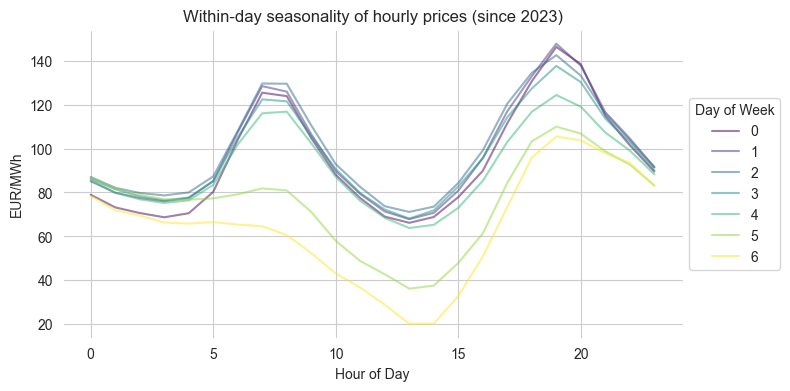

In [282]:
# Inspect seasonality within a day since 2023
fig, ax = plt.subplots(figsize=(8,4)) 

pd.pivot_table(data=df_final[df_final['timestamp'].dt.year>2022][['day_of_week', 'hour', 'price']], index='hour', columns='day_of_week') \
    ['price'] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='Day of Week', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title='Within-day seasonality of hourly prices (since 2023)', ylabel=r'EUR/MWh', xlabel='Hour of Day');

### Supply-Demand Mechanism

In [286]:
# Define residual load
df_final['residual_load'] = df_final['actual_load'] - df_final['actual_wind_onshore'] - df_final['actual_wind_offshore'] - df_final['actual_solar']

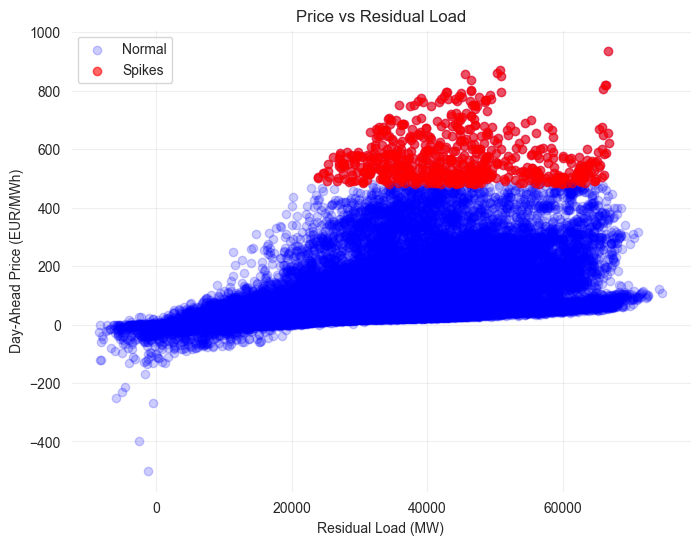

In [287]:
plt.figure(figsize=(8,6))

# scatter: all points, faint
plt.scatter(df_final['residual_load'], df_final['price'], alpha=0.2, label='Normal', color='blue')

# optional: highlight spikes
upper_threshold = df_final['price'].quantile(0.99)
plt.scatter(
    df_final.loc[df_final['price'] > upper_threshold, 'residual_load'],
    df_final.loc[df_final['price'] > upper_threshold, 'price'],
    color='red', alpha=0.6, label='Spikes'
)

plt.xlabel("Residual Load (MW)")
plt.ylabel("Day-Ahead Price (EUR/MWh)")
plt.title("Price vs Residual Load")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

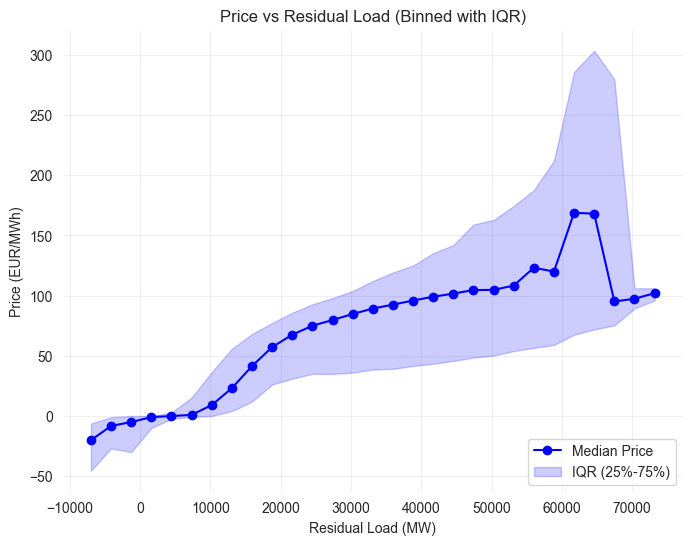

In [288]:
# Create residual load bins
bins = np.linspace(df_final['residual_load'].min(), df_final['residual_load'].max(), 30)
df_final['residual_bin'] = pd.cut(df_final['residual_load'], bins)

# Compute statistics per bin
binned_stats = df_final.groupby('residual_bin')['price'].agg([
    ('median', 'median'),
    ('q25', lambda x: x.quantile(0.25)),
    ('q75', lambda x: x.quantile(0.75))
]).reset_index()

# Bin centers for plotting
bin_centers = [interval.mid for interval in binned_stats['residual_bin']]

# Plot
plt.figure(figsize=(8,6))

# Plot median
plt.plot(bin_centers, binned_stats['median'], marker='o', linestyle='-', color='blue', label='Median Price')

# Shade interquartile range
plt.fill_between(bin_centers, binned_stats['q25'], binned_stats['q75'], color='blue', alpha=0.2, label='IQR (25%-75%)')

plt.xlabel("Residual Load (MW)")
plt.ylabel("Price (EUR/MWh)")
plt.title("Price vs Residual Load (Binned with IQR)")
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.show()

### Power system balance plot

In [289]:
df = df_final.copy()

df['other_generation'] = (
    df['total_generation']
    - df['coal_generation']
    - df['gas_generation']
    - df['nuclear_generation']
    - df['actual_wind_offshore']
    - df['actual_wind_onshore']
    - df['actual_solar']
)

In [290]:
# net import
df['net_import'] = -df['net_export']

In [291]:
# define two periods
period1 = df[df['timestamp'].dt.year <= 2022]
period2 = df[df['timestamp'].dt.year >= 2023]

# calculate period averages
avg1 = period1.mean(numeric_only=True)
avg2 = period2.mean(numeric_only=True)

In [292]:
# select generation stack
gen_cols = [
    'coal_generation',
    'gas_generation',
    'nuclear_generation',
    'actual_wind_offshore',
    'actual_wind_onshore',
    'actual_solar',
    'other_generation'
]

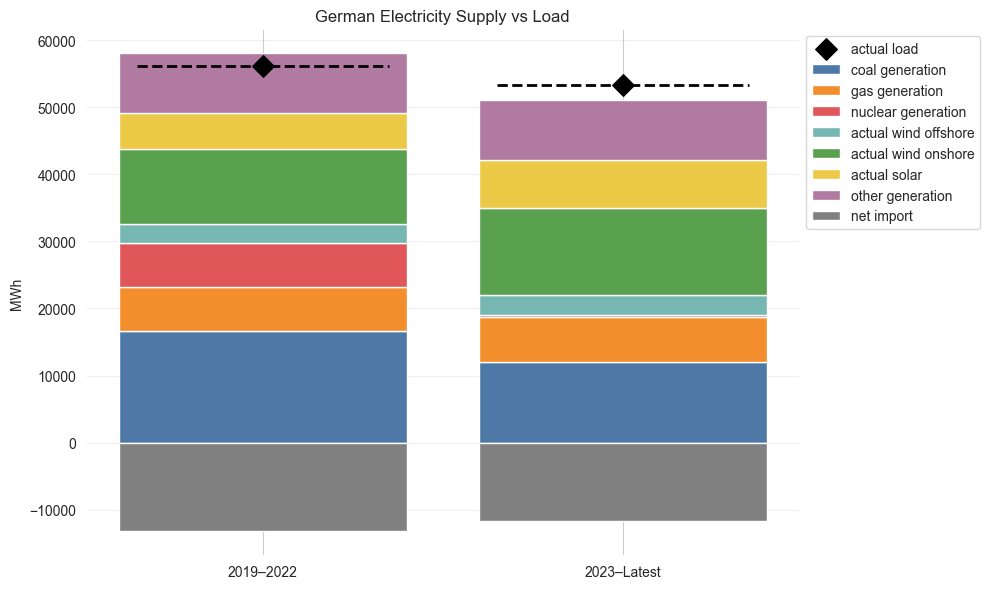

In [ ]:
# Plot chart
# Check if identity "Total generation + Net import = Actual load" is satisfied

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,6))

x = [0, 1]

bottom1 = 0
bottom2 = 0

colors = [
    '#4E79A7',
    '#F28E2B',
    '#E15759',
    '#76B7B2',
    '#59A14F',
    '#EDC948',
    '#B07AA1'
]

# stacked generation
for col, color in zip(gen_cols, colors):

    ax.bar(x[0], avg1[col], bottom=bottom1,
           color=color, label=col.replace('_',' '))
    ax.bar(x[1], avg2[col], bottom=bottom2,
           color=color)

    bottom1 += avg1[col]
    bottom2 += avg2[col]


# add net imports
ax.bar(
    x[0],
    avg1['net_import'],
    bottom=bottom1 if avg1['net_import'] >= 0 else 0,
    color='grey',
    label='net import'
)

ax.bar(
    x[1],
    avg2['net_import'],
    bottom=bottom2 if avg2['net_import'] >= 0 else 0,
    color='grey'
)


# actual load as diamond
ax.scatter(
    x[0], avg1['actual_load'],
    marker='D', s=120, color='black',
    label='actual load', zorder=5
)

ax.scatter(
    x[1], avg2['actual_load'],
    marker='D', s=120, color='black',
    zorder=5
)

line_width = 0.35  # controls how wide the line extends

ax.hlines(
    y=avg1['actual_load'],
    xmin=x[0] - line_width,
    xmax=x[0] + line_width,
    colors='black',
    linestyles='dashed',
    linewidth=2
)

ax.hlines(
    y=avg2['actual_load'],
    xmin=x[1] - line_width,
    xmax=x[1] + line_width,
    colors='black',
    linestyles='dashed',
    linewidth=2
)

ax.set_xticks(x)
ax.set_xticklabels(['2019–2022', '2023–Latest'])

ax.set_ylabel('MWh')
ax.set_title('German Electricity Supply vs Load')

ax.legend(loc='upper left', bbox_to_anchor=(1,1))
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### ACF-PACF

In [295]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import adfuller
from scipy import signal
%matplotlib inline

# If you want a style choose one
#plt.style.use('Solarize_Light2')
#plt.style.use('tableau-colorblind10')
NF_ORANGE = '#ff5a36'
NF_BLUE = '#163251'

In [ ]:
# define functions (copied from course notebook "Time_Series_Decompose_Smoothing.ipynb")

def plot_acf_pacf(ts, lags=10, layout='h'):
    """
    Plots the empirical ACF and PACF of a time series process.
    
        Args:
        ts: array of time series
        
        Returns:
        matplotlib subplot with ACF and PACF
    """
    if layout == 'h':
        fig, ax = plt.subplots(1, 2, figsize = (10,3))
    else: 
        fig, ax = plt.subplots(2, 1, figsize = (10,3))
    sm.tsa.graphics.plot_acf(ts,color = NF_ORANGE,lags=lags, ax = ax[0])
    sm.tsa.graphics.plot_pacf(ts,color = NF_ORANGE, lags = lags, ax = ax[1])    

def diff_series(ts, interval=1):
    """
    Differences a time series by a certain lag.
    
        Args:
        ts: array of 1d time series
        
        Returns:
        Differenced time series
    """
    diff = ts[interval:] - ts[:-interval]
    return diff

def kpss_test(ts):
    """
    Performs a KPSS test for the null hypothesis of stationarity.
    
        Args:
        ts: 1d time series
        
        Returns:
        Summary of test statistic and critical values
    """
    print ('Results of KPSS Test:')
    kpsstest = kpss(ts, regression='c', nlags='legacy')
    kpss_output = pd.Series(kpsstest[0:3], index=['Test Statistic','p-value','Lags Used'])
    for key,value in kpsstest[3].items():
        kpss_output['Critical Value (%s)'%key] = value
    print (kpss_output)

def adf_test(ts):
    """
    Performs a Dickey-Fuller test for the null hypothesis of
    non-stationarity.
    
        Args:
        ts: 1-d time series
    
        Returns:
        Printed test statistic and critical values.
    """
    print ('Results of Dickey-Fuller Test:')
    dftest = adfuller(ts, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic','p-value','#Lags Used',
                                             'Number of Observations Used'])
    for key,value in dftest[4].items():
        dfoutput['Critical Value (%s)'%key] = value
    print(dfoutput)

In [300]:
# only period2 prices
period2 = df_final[df_final['timestamp'].dt.year >= 2023].copy()
price_np = period2['price'].to_numpy()
type(price_np)

numpy.ndarray

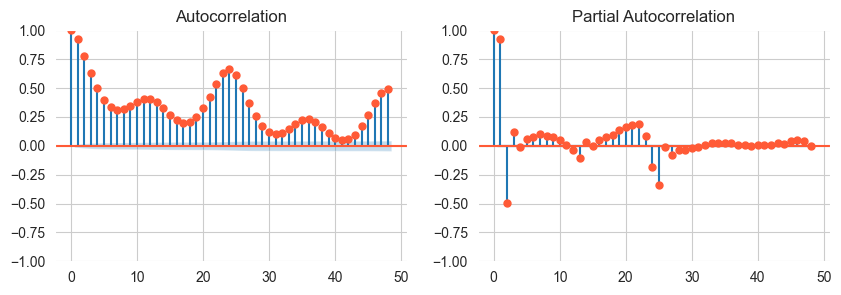

In [304]:
# ACF-PACF for day-head price since 2023
plot_acf_pacf(price_np, lags=48)

In [303]:
# take the 24-hour difference
d24h_price_np = diff_series(price_np, interval=24)

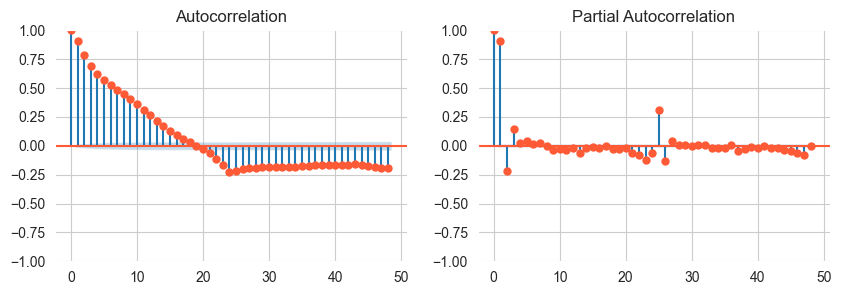

In [ ]:
# ACF-PACF for the 24-hour-differenced price (since 2023)
plot_acf_pacf(d24h_price_np, lags=48)